In [2]:
import pandas as pd

pepe_data = pd.read_parquet("md/binance-futures_book_snapshot_25_2024-11-01_1000PEPEUSDT.parquet")
btc_data = pd.read_parquet("md/binance-futures_book_snapshot_25_2024-11-01_BTCUSDT.parquet")
eth_data = pd.read_parquet("md/binance-futures_book_snapshot_25_2024-11-01_ETHUSDT.parquet")
mew_data = pd.read_parquet("md/binance-futures_book_snapshot_25_2024-11-01_MEWUSDT.parquet")
sol_data = pd.read_parquet("md/binance-futures_book_snapshot_25_2024-11-01_SOLUSDT.parquet")


In [46]:
pepe_data

,local_timestamp,asks[0].price,asks[0].amount,bids[0].price,bids[0].amount,asks[1].price,asks[1].amount,bids[1].price,bids[1].amount,asks[2].price,...,asks[24].price,asks[24].amount,bids[24].price,bids[24].amount,PEPEUSDT_mid_price,PEPEUSDT_spread,PEPEUSDT_weighted_mid_price,PEPEUSDT_imbalance,PEPEUSDT_asks,PEPEUSDT_bids
0,1730419201051657,0.009116,462474,0.009116,1423216,0.009116,2745,0.009115,2745,0.009116,...,0.009119,407960,0.009113,271960,0.009116,1.000000e-07,0.009116,0.509491,462474,1423216
1,1730419202554942,0.009116,542550,0.009116,1351513,0.009116,2745,0.009115,2745,0.009116,...,0.009119,407960,0.009113,271960,0.009116,1.000000e-07,0.009116,0.427105,542550,1351513
2,1730419204074041,0.009116,401496,0.009116,1293027,0.009116,2745,0.009115,2745,0.009116,...,0.009119,407960,0.009113,271960,0.009116,1.000000e-07,0.009116,0.526125,401496,1293027
3,1730419204129207,0.009118,81699,0.009116,762292,0.009118,220174,0.009116,63425,0.009118,...,0.009120,648678,0.009113,402760,0.009117,1.500000e-06,0.009117,0.806398,81699,762292
4,1730419204174582,0.009119,212603,0.009116,762292,0.009119,549,0.009116,63425,0.009119,...,0.009122,577800,0.009113,402760,0.009118,3.000000e-06,0.009117,0.563844,212603,762292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1597757,1730505599764648,0.008882,249546,0.008882,2518259,0.008882,2969,0.008882,184534,0.008883,...,0.008885,354756,0.008880,162766,0.008882,1.000000e-07,0.008882,0.819679,249546,2518259
1597758,1730505599817033,0.008882,249546,0.008882,2334581,0.008882,2969,0.008882,184534,0.008883,...,0.008885,354756,0.008880,44744,0.008882,1.000000e-07,0.008882,0.806862,249546,2334581
1597759,1730505599867503,0.008882,1128,0.008882,2336439,0.008882,2969,0.008882,184534,0.008883,...,0.008885,202421,0.008880,44744,0.008882,1.000000e-07,0.008883,0.999035,1128,2336439
1597760,1730505599919869,0.008883,767,0.008882,749893,0.008883,563,0.008882,642550,0.008883,...,0.008885,92977,0.008880,734810,0.008883,1.000000e-07,0.008883,0.997956,767,749893


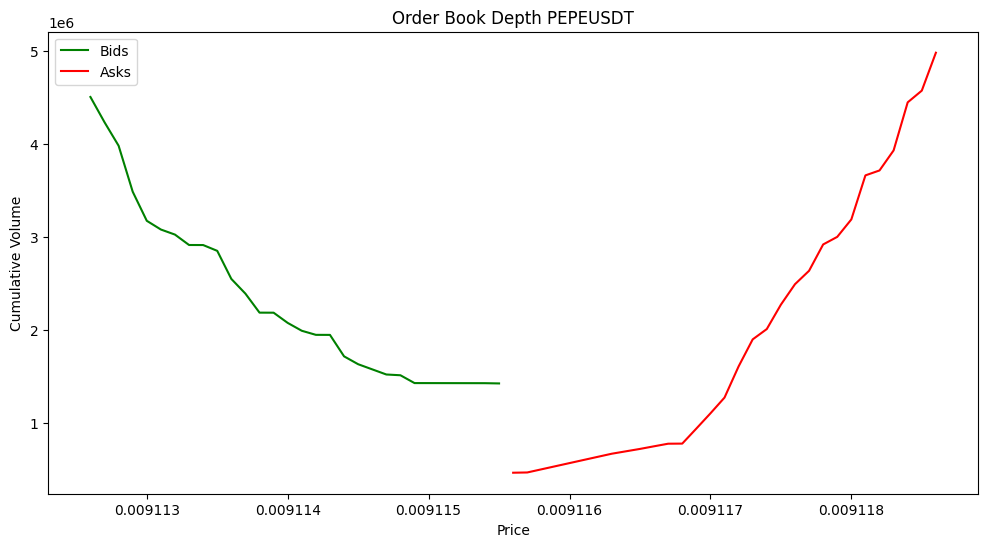

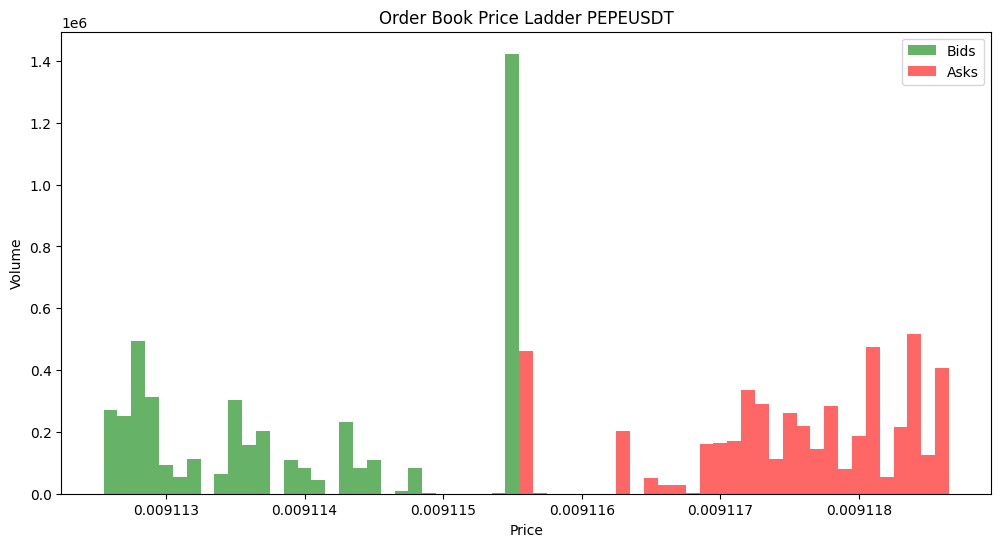

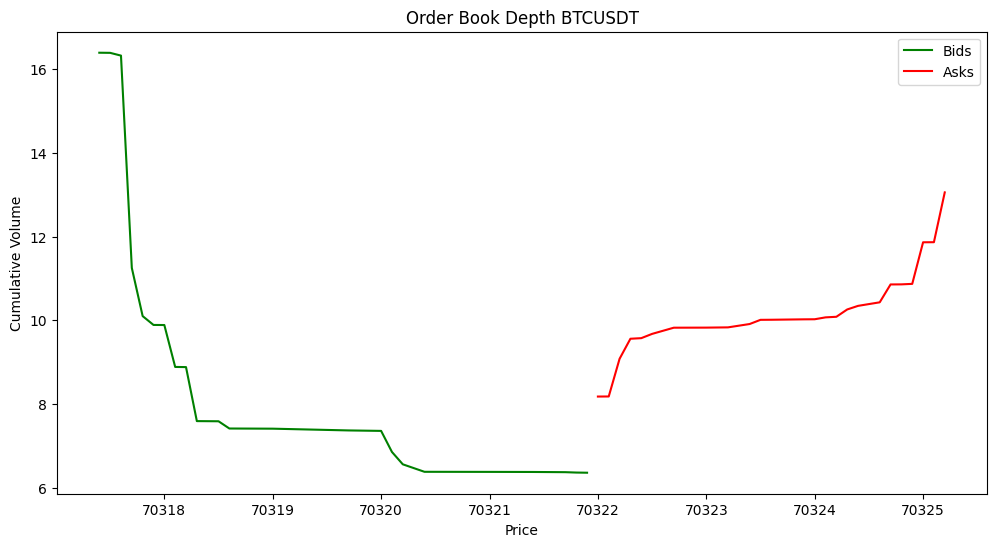

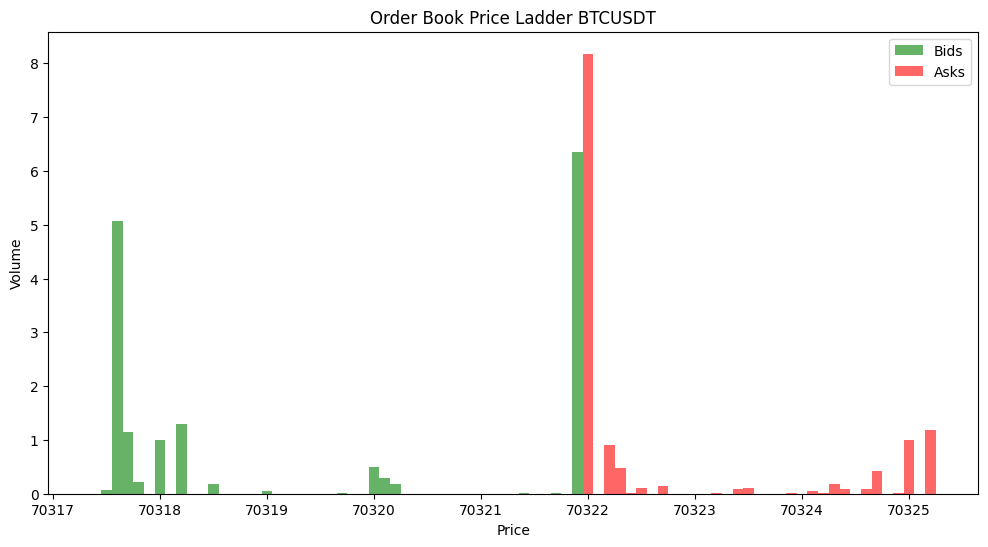

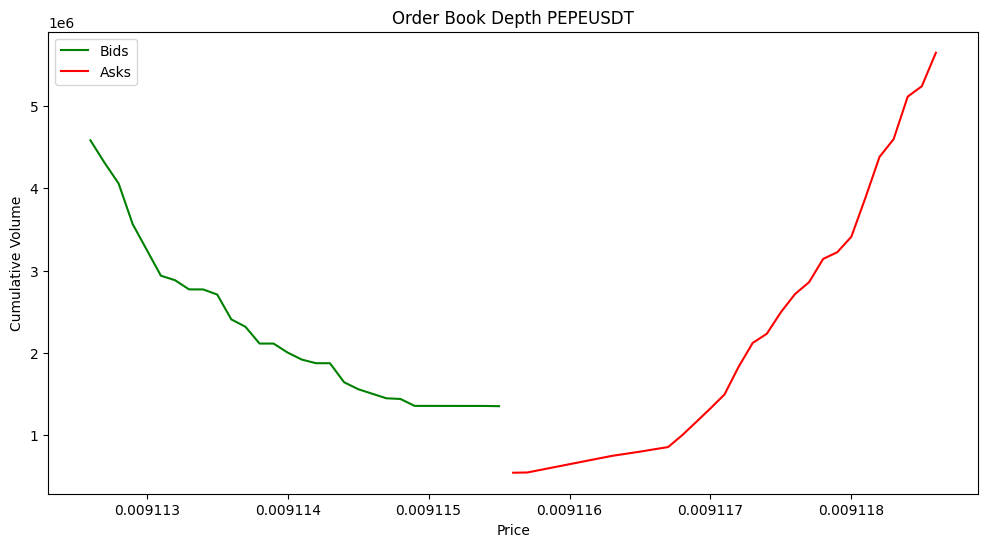

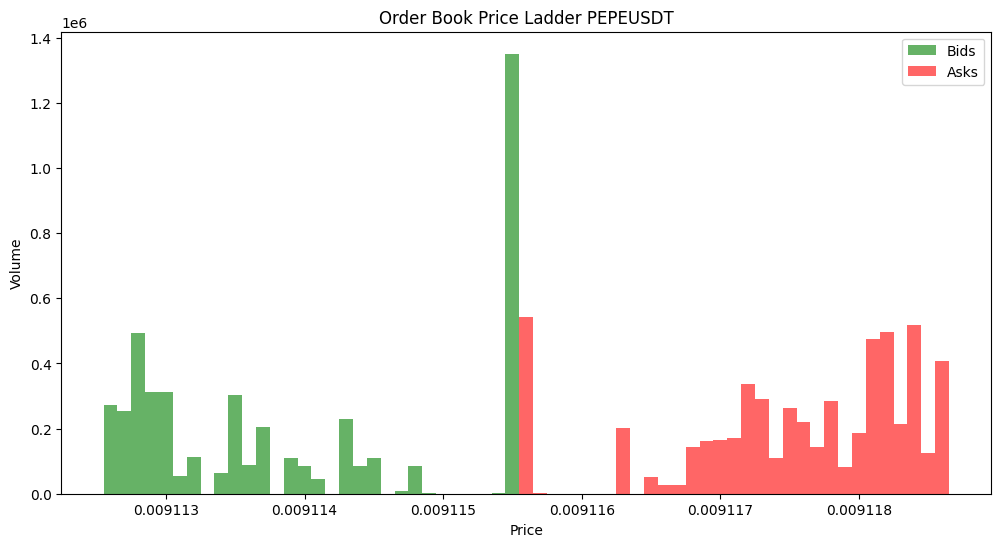

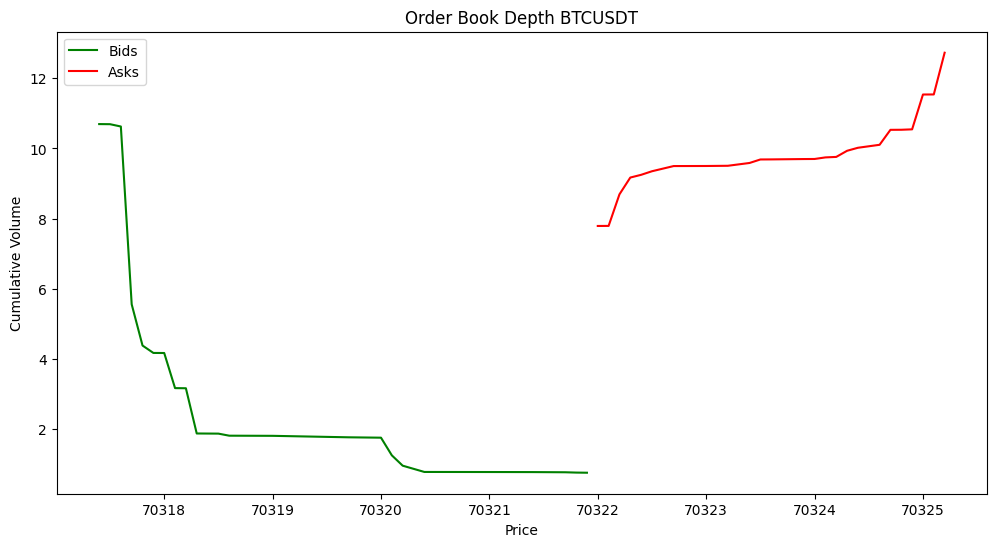

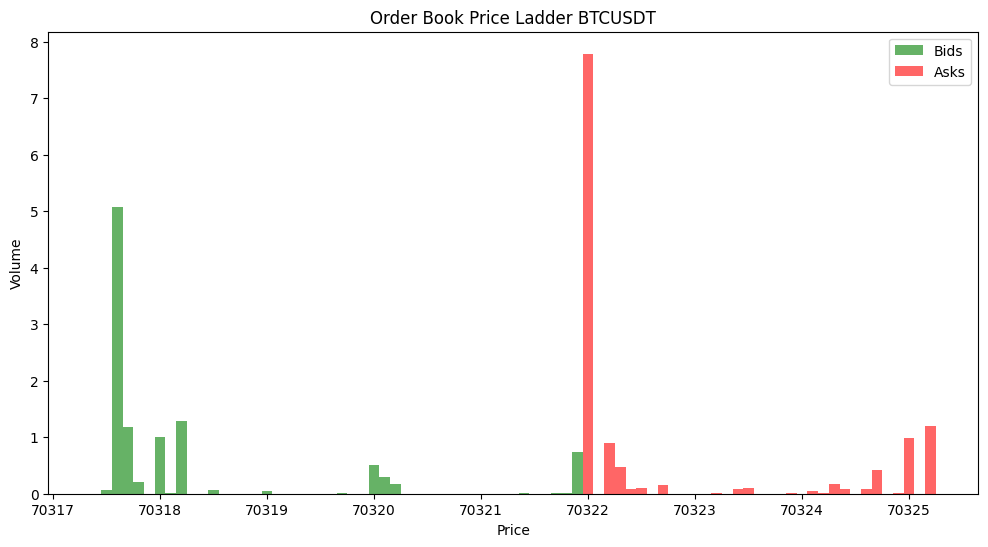

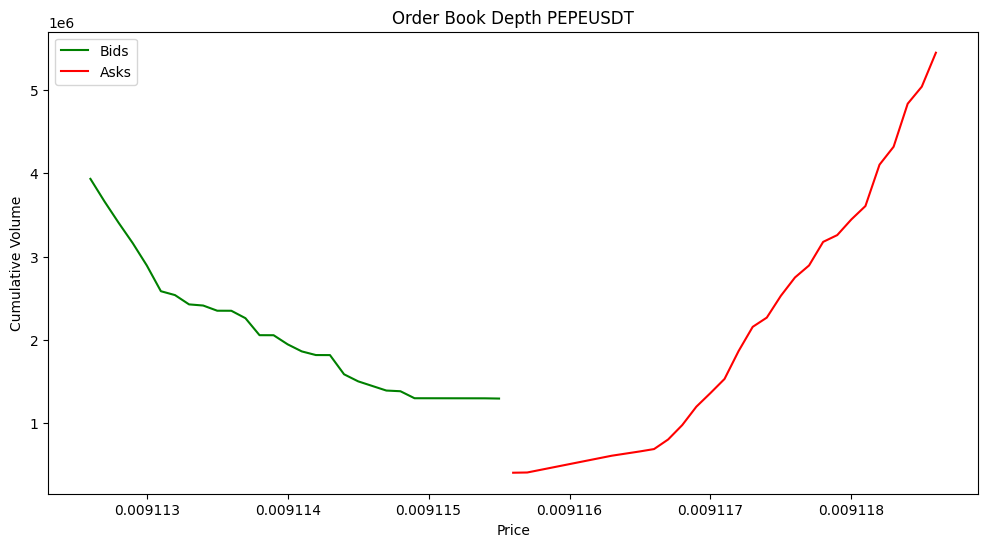

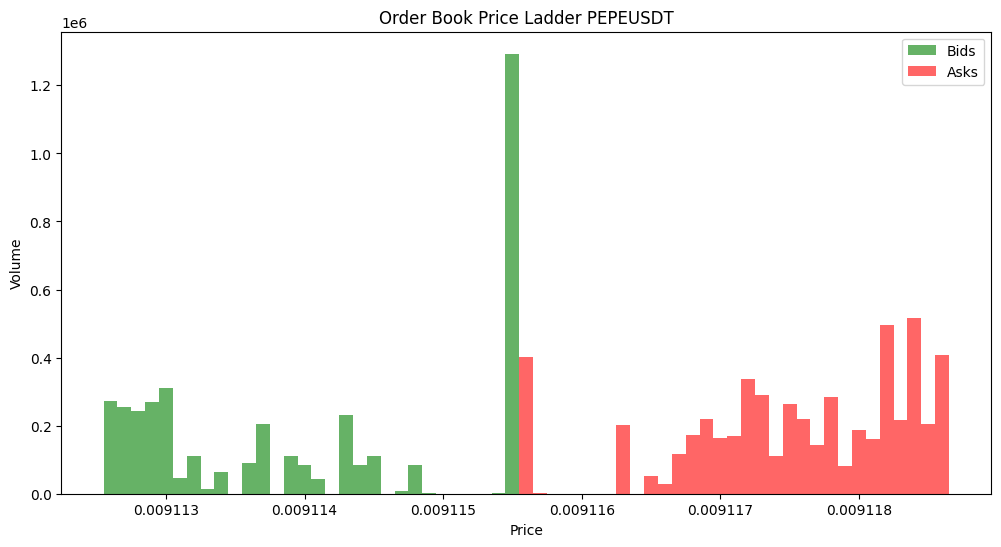

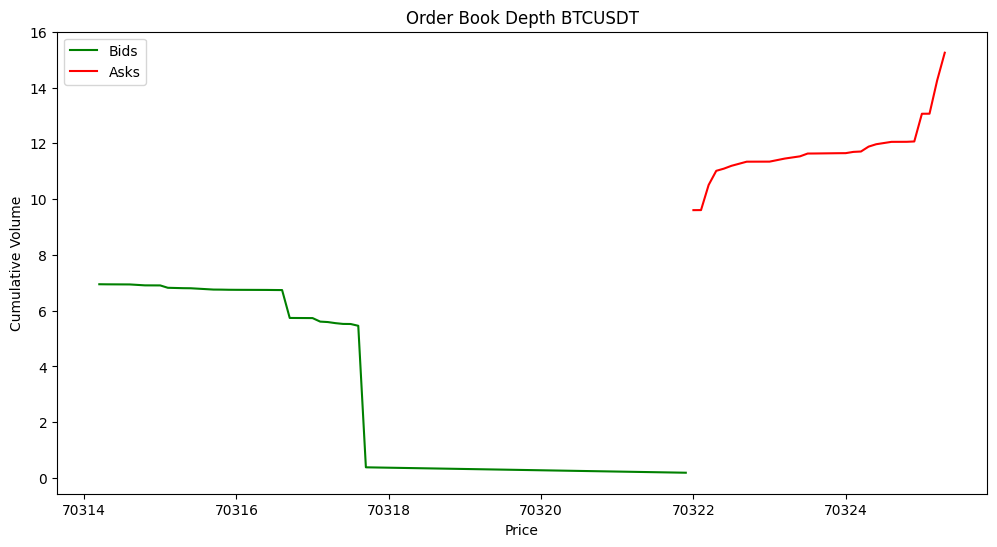

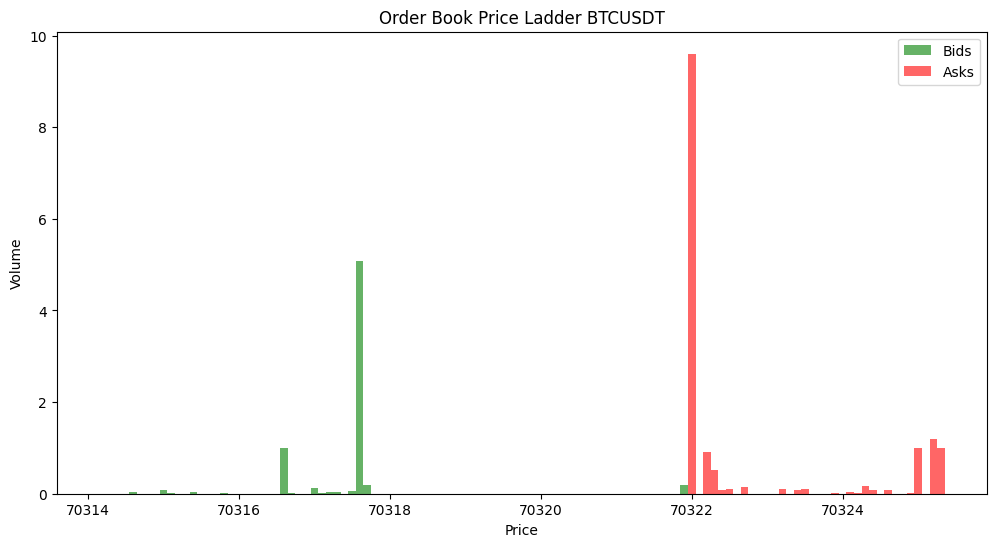

In [20]:
import matplotlib.pyplot as plt

names = ['PEPEUSDT', 'BTCUSDT', 'ETHUSDT', 'MEWUSDT', 'SOLUSDT']
for j in range(3):
    snapshots = [pepe_data.iloc[j], btc_data.iloc[j], eth_data.iloc[j], mew_data.iloc[j], sol_data.iloc[j]]

    for i, snapshot in enumerate(snapshots[:2]):
        ask_prices = [snapshot[f"asks[{i}].price"] for i in range(25)]
        ask_volumes = [snapshot[f"asks[{i}].amount"] for i in range(25)]
        bid_prices = [snapshot[f"bids[{i}].price"] for i in range(25)]
        bid_volumes = [snapshot[f"bids[{i}].amount"] for i in range(25)]

        cumulative_ask_volumes = list(pd.Series(ask_volumes).cumsum())
        cumulative_bid_volumes = list(pd.Series(bid_volumes).cumsum())

        plt.figure(figsize=(12, 6))
        plt.plot(bid_prices, cumulative_bid_volumes, label="Bids", color="green")
        plt.plot(ask_prices, cumulative_ask_volumes, label="Asks", color="red")
        plt.xlabel("Price")
        plt.ylabel("Cumulative Volume")
        plt.title(f"Order Book Depth {names[i]}")
        plt.legend()
        plt.show()

        plt.figure(figsize=(12, 6))
        width = abs(ask_prices[0] - ask_prices[1])
        plt.bar(bid_prices, bid_volumes, color="green", alpha=0.6, width=width, label="Bids")
        plt.bar(ask_prices, ask_volumes, color="red", alpha=0.6, width=width, label="Asks")
        plt.xlabel("Price")
        plt.ylabel("Volume")
        plt.title(f"Order Book Price Ladder {names[i]}")
        plt.legend()
        plt.show()

1. Order Book Depth:

BTCUSDT: Large volumes of orders.

2. Liquidity Changes at Best Bid and Ask Prices:

PEPEUSDT: Volumes at best bid and ask are stable within few timestamps.   

3. Volume Distribution Across Price Levels:

PEPEUSDT: The price ladder shows smaller and more evenly distributed volumes across bid and ask price levels.   

4. Imbalance:

BTCUSDT: Higher imbalance.


1. Volume Imbalance Ratio:
    - Formula: Volume Imbalance = |Buy Volume - Sell Volume| / Total Volume

2. Order Consistency Ratio:
    - Formula: Order Consistency Ratio = Standard Deviation of Order Sizes / Mean Order Size

3. Market Depth Ratio:
    - Calculate changes in market depth, focusing on gradual reductions on one side of the order book.
    
4. Price Movement Slope:
    - Formula: Use linear regression on price over time and analyze the slope.

5. Spread:
    - Formula: Spread = Best ask price - Best bid price

In [21]:
def calculate_mid_price(row):
    best_ask = row['asks[0].price']
    best_bid = row['bids[0].price']
    return (best_ask + best_bid) / 2

def calculate_spread(row):
    best_ask = row['asks[0].price']
    best_bid = row['bids[0].price']
    return best_ask - best_bid

def calculate_weighted_mid_price(row, num_levels=5):
    ask_prices = [row[f'asks[{i}].price'] for i in range(num_levels)]
    ask_amounts = [row[f'asks[{i}].amount'] for i in range(num_levels)]
    bid_prices = [row[f'bids[{i}].price'] for i in range(num_levels)]
    bid_amounts = [row[f'bids[{i}].amount'] for i in range(num_levels)]
    
    total_ask_volume = sum(ask_amounts)
    total_bid_volume = sum(bid_amounts)
    
    weighted_ask_price = sum(p * a for p, a in zip(ask_prices, ask_amounts)) / total_ask_volume
    weighted_bid_price = sum(p * b for p, b in zip(bid_prices, bid_amounts)) / total_bid_volume
    
    return (weighted_ask_price + weighted_bid_price) / 2

def calculate_imbalance(row):
    best_ask_amount = row['asks[0].amount']
    best_bid_amount = row['bids[0].amount']
    return (best_bid_amount - best_ask_amount) / (best_bid_amount + best_ask_amount)

In [ ]:
for data, name in zip([pepe_data, btc_data, eth_data, mew_data, sol_data], names):
    data[f'{name}_mid_price'] = data.apply(calculate_mid_price, axis=1)
    data[f'{name}_spread'] = data.apply(calculate_spread, axis=1)
    data[f'{name}_weighted_mid_price'] = data.apply(calculate_weighted_mid_price, axis=1)
    data[f'{name}_imbalance'] = data.apply(calculate_imbalance, axis=1)
    data[f'{name}_asks'] = data['asks[0].amount']
    data[f'{name}_bids'] = data['bids[0].amount']

In [ ]:
def resample(df, column="local_timestamp"):
    df["sampled_timestamp"] = pd.to_datetime(df[column], unit="us")
    df.set_index("sampled_timestamp", inplace=True)
    resampled_df = df.resample("1s").mean().dropna().reset_index()
    return resampled_df

pepe_data_resampled = resample(pepe_data)
btc_data_resampled = resample(btc_data)
eth_data_resampled = resample(eth_data)
mew_data_resampled = resample(mew_data)
sol_data_resampled = resample(sol_data)

name = "PEPEUSDT"
merged_data = pepe_data_resampled[
    [
        "sampled_timestamp",
        f"{name}_asks",
        f"{name}_bids",
        f"{name}_imbalance",
        f"{name}_mid_price",
        f"{name}_spread",
        f"{name}_weighted_mid_price",
    ]
].copy()

for data, name in zip([
    btc_data_resampled,
    eth_data_resampled,
    mew_data_resampled,
    sol_data_resampled,
    ], names[1:]):
    merged_data = merged_data.merge(
        data[[
            "sampled_timestamp",
            f"{name}_asks",
            f"{name}_bids",
            f"{name}_imbalance",
            f"{name}_mid_price",
            f"{name}_spread",
            f"{name}_weighted_mid_price",
        ]],
        on="sampled_timestamp",
        how="inner",
    )

/var/folders/vq/jy3z_vfd6n34bgkww317j7mw0000gq/T/ipykernel_76998/3010070655.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sampled_timestamp"] = pd.to_datetime(df[column], unit="us")
/var/folders/vq/jy3z_vfd6n34bgkww317j7mw0000gq/T/ipykernel_76998/3010070655.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sampled_timestamp"] = pd.to_datetime(df[column], unit="us")
/var/folders/vq/jy3z_vfd6n34bgkww317j7mw0000gq/T/ipykernel_76998/3010070655.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually

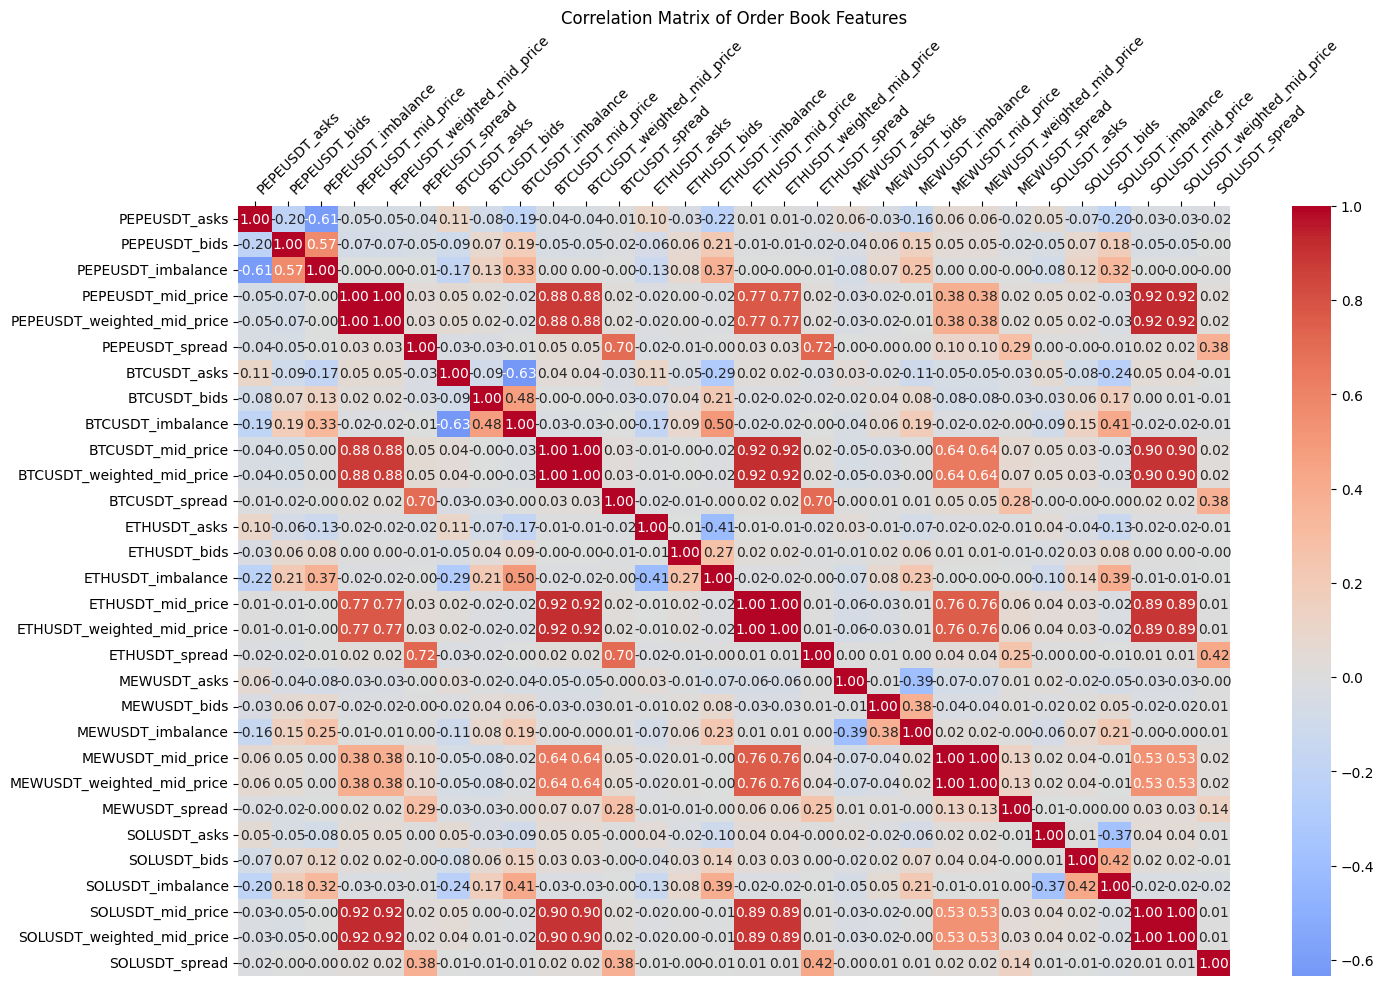

In [58]:
feature_columns = [
    "PEPEUSDT_asks",
    "PEPEUSDT_bids",
    "PEPEUSDT_imbalance",
    "PEPEUSDT_mid_price",
    "PEPEUSDT_weighted_mid_price",
    "PEPEUSDT_spread",
    "BTCUSDT_asks",
    "BTCUSDT_bids",
    "BTCUSDT_imbalance",
    "BTCUSDT_mid_price",
    "BTCUSDT_weighted_mid_price",
    "BTCUSDT_spread",
    "ETHUSDT_asks",
    "ETHUSDT_bids",
    "ETHUSDT_imbalance",
    "ETHUSDT_mid_price",
    "ETHUSDT_weighted_mid_price",
    "ETHUSDT_spread",
    "MEWUSDT_asks",
    "MEWUSDT_bids",
    "MEWUSDT_imbalance",
    "MEWUSDT_mid_price",
    "MEWUSDT_weighted_mid_price",
    "MEWUSDT_spread",
    "SOLUSDT_asks",
    "SOLUSDT_bids",
    "SOLUSDT_imbalance",
    "SOLUSDT_mid_price",
    "SOLUSDT_weighted_mid_price",
    "SOLUSDT_spread",
]

correlation_matrix = merged_data[feature_columns].corr()

import seaborn as sns

plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Order Book Features")
plt.gca().xaxis.set_label_position("top")
plt.gca().xaxis.tick_top()
plt.xticks(rotation=45, ha="left")
plt.show()

As its seen Mid-Prices and WAMP have high correlation between several sets of instruments.

In [69]:
btc_data_resampled['BTCUSDT_mid_price_lag3'] = btc_data_resampled['BTCUSDT_mid_price'].shift(3)
pepe_data_resampled['PEPEUSDT_mid_price_lag3'] = pepe_data_resampled['PEPEUSDT_mid_price'].shift(3)

btc_data_resampled["BTCUSDT_mid_price_diff3"] = (
    btc_data_resampled["BTCUSDT_mid_price"] - btc_data_resampled["BTCUSDT_mid_price_lag3"]
)
pepe_data_resampled["PEPEUSDT_mid_price_diff3"] = (
    pepe_data_resampled["PEPEUSDT_mid_price"]
    - pepe_data_resampled["PEPEUSDT_mid_price_lag3"]
)

diff_mid_price = btc_data_resampled[["sampled_timestamp", "BTCUSDT_mid_price_diff3"]].merge(
    pepe_data_resampled[["sampled_timestamp", "PEPEUSDT_mid_price_diff3"]], on="sampled_timestamp", how="inner"
)

diff_mid_price["BTCUSDT_mid_price_diff3_lag3"] = diff_mid_price[
    "BTCUSDT_mid_price_diff3"
].shift(3)

diff_mid_price["PEPEUSDT_mid_price_diff3_lag3"] = diff_mid_price[
    "PEPEUSDT_mid_price_diff3"
].shift(3)

correlations = {
    "BTCUSDT_leads": diff_mid_price[
        [
            "BTCUSDT_mid_price_diff3_lag3",
            "PEPEUSDT_mid_price_diff3",
        ]
    ].corr(),
    "PEPEUSDT_leads": diff_mid_price[
        [
            "PEPEUSDT_mid_price_diff3_lag3",
            "BTCUSDT_mid_price_diff3",
        ]
    ].corr(),
}

for instr, corr_matrix in correlations.items():
    print(f"\nCorrelation matrix for {instr} leading:")
    print(corr_matrix)


Correlation matrix for BTCUSDT_leads leading:
                              BTCUSDT_mid_price_diff3_lag3  \
BTCUSDT_mid_price_diff3_lag3                      1.000000   
PEPEUSDT_mid_price_diff3                          0.069327   

                              PEPEUSDT_mid_price_diff3  
BTCUSDT_mid_price_diff3_lag3                  0.069327  
PEPEUSDT_mid_price_diff3                      1.000000  

Correlation matrix for PEPEUSDT_leads leading:
                               PEPEUSDT_mid_price_diff3_lag3  \
PEPEUSDT_mid_price_diff3_lag3                       1.000000   
BTCUSDT_mid_price_diff3                             0.152243   

                               BTCUSDT_mid_price_diff3  
PEPEUSDT_mid_price_diff3_lag3                 0.152243  
BTCUSDT_mid_price_diff3                       1.000000  
